# Notebook Apéndice Tema 4 VA, Master IA UMU, curso 2025/26 (motivación necesidad RANSAC/HT)


# Requerimientos previos

Descargamos el módulo de apoyo (`colabutils.py`) e instalamos con `pip` el par de paquetes necesarios para ejecutar el resto del notebook, `ffmpeg` y `mpld3`.

También descargamos una foto de una plantilla con bordes rectos para realizar tests iniciales de detección de rectas.

In [1]:
! wget http://ditec.um.es/~pedroe/colabutils.py -O ./colabutils.py
# LINK ALTERNATIVO:
# wget https://univmurcia-my.sharepoint.com/:u:/g/personal/pedroe_um_es/EduK-BdC3PVOsTG-v3hBfSQBTWxZnNfRwUoRp_PPCSUDAQ?download=1 -O ./colabutils.py
! wget http://ditec.um.es/~pedroe/fotoplantilla.png -O ./fotoplantilla.png
# LINK ALTERNATIVO:
# wget https://univmurcia-my.sharepoint.com/:i:/g/personal/pedroe_um_es/Ef4pO2UcEqZPnW5tBtF8hugBiwWn1lCi_T8rYr1BBZVduA?download=1 -O ./fotoplantilla.png
! pip install ffmpeg
! pip install mpld3

--2025-10-21 08:08:57--  http://ditec.um.es/~pedroe/colabutils.py
Resolving ditec.um.es (ditec.um.es)... 155.54.204.49
Connecting to ditec.um.es (ditec.um.es)|155.54.204.49|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17973 (18K) [text/plain]
Saving to: ‘./colabutils.py’

./colabutils.py     100%[===================>]  17.55K  --.-KB/s    in 0.1s    

2025-10-21 08:08:57 (152 KB/s) - ‘./colabutils.py’ saved [17973/17973]

--2025-10-21 08:08:57--  http://ditec.um.es/~pedroe/fotoplantilla.png
Resolving ditec.um.es (ditec.um.es)... 155.54.204.49
Connecting to ditec.um.es (ditec.um.es)|155.54.204.49|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 310464 (303K) [image/png]
Saving to: ‘./fotoplantilla.png’

./fotoplantilla.png 100%[===================>] 303.19K   649KB/s    in 0.5s    

2025-10-21 08:08:58 (649 KB/s) - ‘./fotoplantilla.png’ saved [310464/310464]



Recordar que todos los paquetes (`apt` y/o `pip`) instalados de esta forma, así como los ficheros descargados, modifican el entorno de ejecución subyacente, que se ejecutará siempre en la nube. De forma que para cada nueva ejecución del notebook deberá ejecutarse esta inicialización, ya que nuestros entornos de ejecución en la nube se resetean al desconectarnos.

# Imports necesarios

In [2]:
import cv2
import numpy as np
import scipy.linalg
from ipywidgets import interact, interactive_output, fixed, IntSlider, IntRangeSlider, FloatSlider
import colabutils
import mpld3
import matplotlib.pyplot as plt

# Imagen de entrada

Recordar también que siempre que vayamos a trabajar en una práctica, necesitaremos alguna(s) imagen(es) de entrada con la(s) que poder probar nuestros algoritmos. En este caso la leemos del archivo `fotoplantilla.png` subido previamente. Aunque si disponemos de _webcam_, también se puede capturar la imagen directamente desde la misma, usando p.e. la función `webcam2numpy()` del paquete `colabutils`:

**Nota:** Si escogemos la opción de la webcam, la siguiente celda no retornará el control hasta que se haya pulsado con el ratón sobre ella para capturar la imagen.

In [3]:
# imgwc = colabutils.webcam2numpy()
imgwc = cv2.cvtColor(cv2.imread("./fotoplantilla.png"), cv2.COLOR_BGR2RGB) # Intercambio de canales B y R, siguiendo convenio de OpenCV.

Empleamos aquí la utilidad `imshow()` de `colabutils` para comprobar rápidamente la imagen leída (recordar que hay bastantes más alternativas, como, p.e., la función `imshow` de matplotlib):

<IPython.core.display.Javascript object>


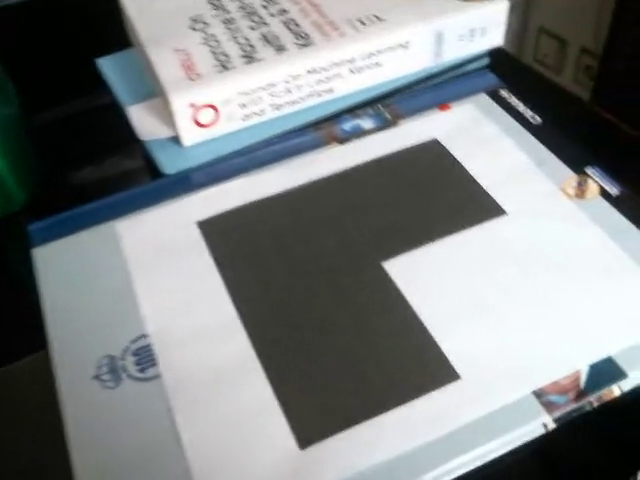

<IPython.core.display.Javascript object>

In [4]:
colabutils.imshow(imgwc)

# Funciones auxiliares

A menudo necesitaremos una cierta cantidad de funciones de apoyo para nuestro _script_. Es una buena práctica, que mejora bastante la legibilidad de los notebooks, ubicar todas esas _funciones auxiliares_ en una sección dedicada, tal como esta.

## Funciones auxiliares para dibujar

Función auxiliar para dibujar texto (con contraste adecuado) en una imagen. Esta función escribe una cadena de texto en negro, y encima una equivalente en blanco, para lograr siempre el contraste deseado, independientemente de los colores subyacentes en la posición de la imagen donde vamos a escribir:

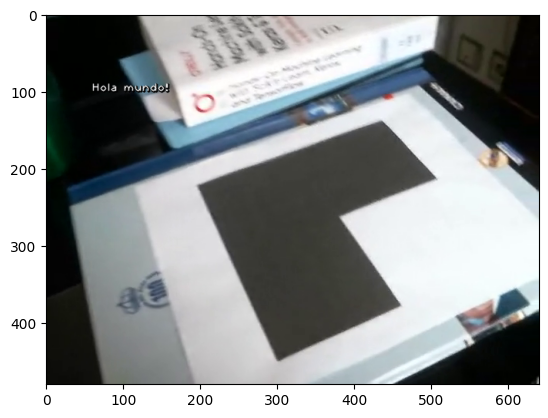

In [5]:
def draw_str(dst, tuplexy, s):
    (x,y) = tuplexy
    # Empleamos la función putText de la OpenCV:
    cv2.putText(dst, s, (x+1, y+1), cv2.FONT_HERSHEY_PLAIN, 1.0, (0, 0, 0),
                thickness=2, lineType=cv2.LINE_AA)
    cv2.putText(dst, s, (x, y), cv2.FONT_HERSHEY_PLAIN, 1.0, (255, 255, 255),
                lineType=cv2.LINE_AA)

# Escribimos sobre una copia de la imagen, para no sobreescribir la original:
imgcopy = imgwc.copy()
draw_str(imgcopy, (59,100), "Hola mundo!")
# Usamos ahora matplotlib para mostrar la imagen:
plt.imshow(imgcopy);
# El punto y coma en la última instrucción de una celda evita la impresión del
# posible objeto devuelto por la misma (en este caso, el objeto matplotlib.image,
# que simplemente deseamos que se muestre sin ningún otro texto asociado)

Como se ve en el ejemplo anterior, suele ser también una buena práctica hacer una llamada de prueba tras la definición de la función, para demostrar su correcto funcionamiento.

## Figuras matplotlib interactivas

La imagen anterior, mostrada en este caso usando `matplotlib`, aparece algo pequeña en el notebook:

* Si queremos mostrar la imagen más grande, podemos emplear `plt.figure(figsize(ancho,alto))`.

* Si, además, queremos permitir interactividad con el gráfico de `matplotlib`, podemos "embeber" nuestra llamada a las funciones de dicha librería entre sendas llamadas `enable_notebook()` y `disable_notebook()`, correspondientes a la librería de apoyo `mpld3`.

El siguiente _snippet_ de código ilustra ambas posibilidades a la vez:

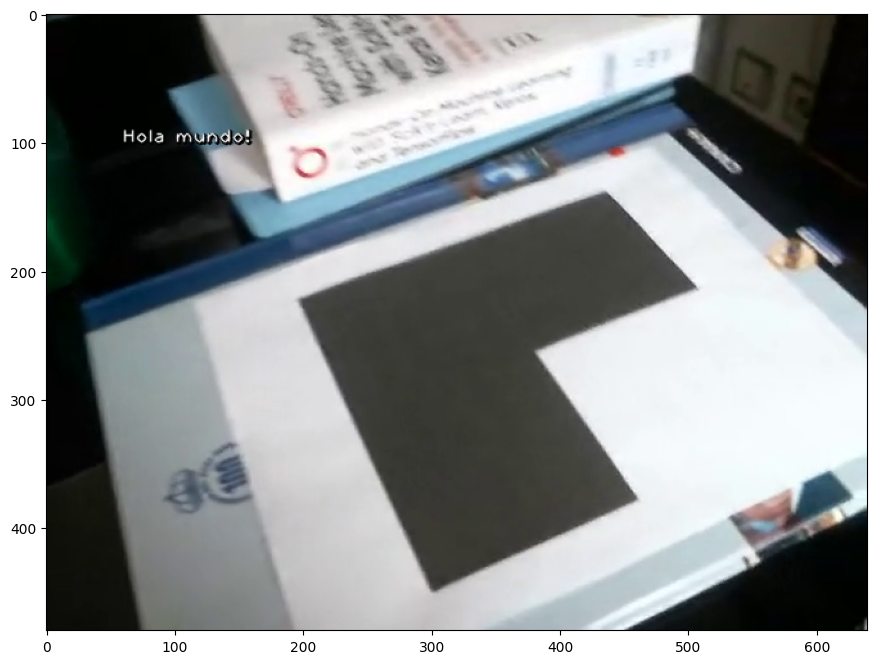

In [6]:
mpld3.enable_notebook()
plt.figure(figsize=(12,8))
plt.imshow(imgcopy)
plt.show()
mpld3.disable_notebook()

En este punto, se puede colocar el ratón encima de la imagen, y jugar con las posibilidades de zoom y movimiento por la imagen ofrecidas al clicar en los correspondientes iconos que aparecerán abajo a la izquierda de la imagen.

##Funciones auxiliares de cómputo

Comenzamos ahora a definir algunas funciones específicas de proceso de imagen. Por ejemplo, definamos primero una imagen de test, consistente en una especie de "ola" inclinada, junto con un umbralizado y la posterior detección de bordes blanco/negro sobre la misma:

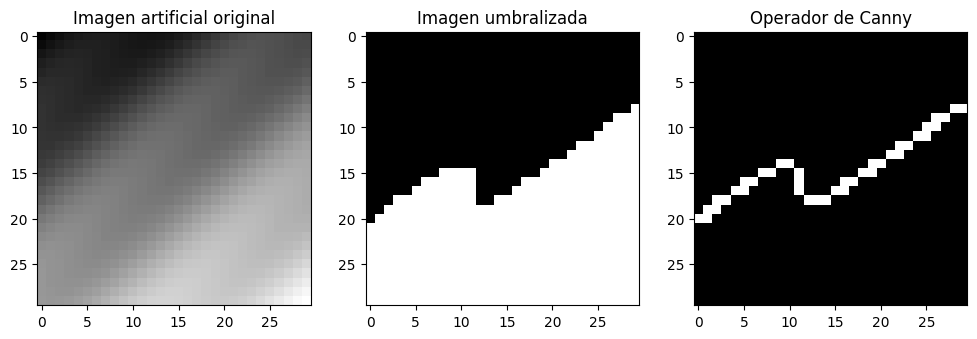

In [7]:
# Definición de un meshgrid (resulta muy instructivo, para entender lo que
# hace esta función de numpy, inspeccionar los valores de x e y generados):
x, y = np.meshgrid(np.linspace(0, 1, 30),np.linspace(0, 1, 30))

# Definición, umbralizado, y operador de bordes de Canny:
imgwave = -1.5 + x + 2*y + 0.2*np.sin(10*x+10*y)
imgwavethr = (255*(imgwave>0)).astype('uint8')
imgcanny = cv2.Canny(imgwavethr, 100, 200)

fig, axs = plt.subplots(1,3, figsize=(12,4))
axs[0].imshow(imgwave,cmap='gray')
axs[0].set_title("Imagen artificial original")
axs[1].imshow(imgwavethr,cmap='gray');
axs[1].set_title("Imagen umbralizada")
axs[2].imshow(imgcanny,cmap='gray');
axs[2].set_title("Operador de Canny");

Extraemos ahora la lista de coordenadas de puntos activos en la última imagen, y calculamos su punto medio (*centro de masas*). Obsérvense varias cosas:
* La coordenada Y suele incrementarse de arriba a abajo en las imágenes originales (coincidiendo con los números de fila de la imagen), pero de abajo a arriba en `plots` vectoriales (puntos, líneas, etc.) de `matplotlib`.
* El uso eficiente y elegante de las diferentes funciones y el indexado de numpy.
* En particular, son interesantes el uso de `::-1` para invertir el orden en un eje, y de la especificación de un eje particular (`axis=0`) para aplicar la función (en este caso en `np.sum`).
* El uso de la función `np.nonzero` para convertir una imagen binarizada a la correspondiente lista de puntos activos en la imagen.

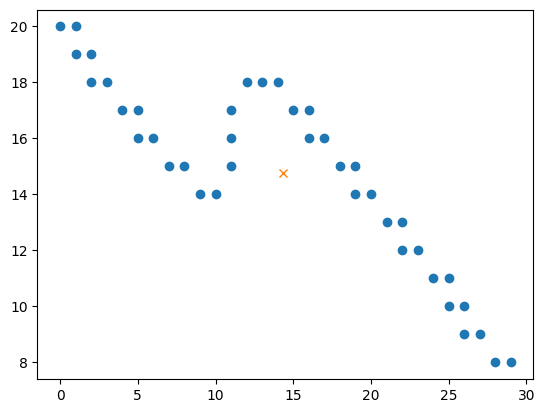

In [8]:
# Intercambiamos (fila, columna), por (x,y)
points = np.transpose(np.nonzero(imgcanny))[:,::-1]
plt.plot(points[:,0],points[:,1],'o')

# Punto medio:
center = np.sum(points, axis=0) / float(len(points))
plt.plot(center[0],center[1],'x');

A partir de los puntos anteriores, pero convenientemente centrados, calculamos matriz de covarianza, y su _eigendescomposición_. De nuevo, notar aquí:
* El uso de @ para realizar un producto (*dot product*) entre matrices y/o vectores.
* Las descomposiciones matriciales más importantes que usaremos en el curso se encuentran en los módulos `np.linalg` y `scipy.linalg`.

In [9]:
centeredpoints = points - center
covmatrix = centeredpoints.T @ centeredpoints / float(len(centeredpoints))
(eigvals, eigmat) = scipy.linalg.eigh(covmatrix)
print("Valores propios:\n", eigvals)
print("Vectores propios:\n", eigmat)

Valores propios:
 [ 2.29092933 84.01594567]
Vectores propios:
 [[-0.3224366  -0.94659106]
 [-0.94659106  0.3224366 ]]


La eigendescomposición no debe intimidarnos; las propiedades más importantes de la misma quedan ilustradas muy simplemente al evaluar la siguiente celda. En particular:
* La eigendescomposición de una matriz simétrica $A_{n\times n}$ produce una lista de valores $\mathbf{v} = (v_1, ..., v_n)$ (valores propios), y una matriz $V_{n \times n}$, de tamaño igual a la original.
* $V$ es ortonormal; es decir, tanto sus filas como sus columnas son vectores unitarios (tienen norma uno), y además, son perpendiculares entre sí. Por tanto, siempre se cumple que $V^T \cdot V =V \cdot V^T = I$, con $I_{n \times n}$ la identidad. Se trata de las conocidas matrices de rotación en 2D, 3D (y en general cualquier dimensión, $R_{n\times n}$), en las que la inversa coincide simplemente con la transpuesta ($R^T \cdot R = R \cdot R^T = I \quad ⇔ \quad R^{-1} = R^T $).
* La matriz original se reconstruye (de ahí el nombre de *descomposición*) con la expresión $A = V \cdot diag(\mathbf{v}) \cdot V^T$, donde $diag(\mathbf{v})$ es simplemente una matriz cuadrada inicialmente llena de ceros, en la que su diagonal principal ha sido reemplazada por los $n$ elementos de $\mathbf{v}$.

Comprobación de todo ello:

In [10]:
print("Matriz de covarianza original:")
print(covmatrix)
print("\nOrtonormalidad de V (matriz de vectores propios):")
print(eigmat @ eigmat.T)
print("\nMatriz diagonal construida con los valores propios:")
print(np.diag(eigvals))
print("\nReconstrucción de la matriz original:")
print(eigmat @ np.diag(eigvals) @ eigmat.T)

Matriz de covarianza original:
[[ 75.519375 -24.94375 ]
 [-24.94375   10.7875  ]]

Ortonormalidad de V (matriz de vectores propios):
[[ 1.00000000e+00 -5.40862793e-18]
 [-5.40862793e-18  1.00000000e+00]]

Matriz diagonal construida con los valores propios:
[[ 2.29092933  0.        ]
 [ 0.         84.01594567]]

Reconstrucción de la matriz original:
[[ 75.519375 -24.94375 ]
 [-24.94375   10.7875  ]]


Lo más interesante para nosotros es que, a partir del centro y del vector propio asociado al mayor valor propio, podemos obtener la recta de regresión que mejor ajusta linealmente los puntos.

* *Nota: De hecho, el otro vector propio es, por las propiedades que discutimos anteriormente, simplemente perpendicular a esta dirección. En general, a las direcciones de los vectores propios obtenidos a partir de una matriz de covarianza (de la dimensión $n$ que sea), se les conoce con el nombre direcciones principales de la distribución de puntos, y son utilizadas en una técnica de reducción de dimensionalidad muy conocida, llamada PCA (o análisis de componentes principales).*

No obstante, aquí tendremos suficiente para determinar la recta que pasa (lo más cerca posible) por un conjunto de puntos con el centro de masas de esos puntos, al que sumamos el primer vector propio (= 1ª dirección principal):

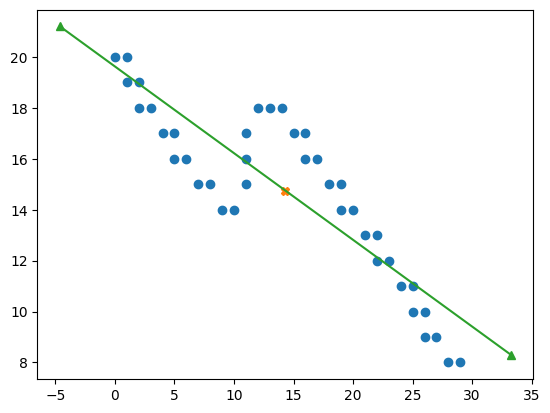

In [11]:
# Dibujamos recta resultado:
p1, p2 = center+20.0*eigmat[1, :], center-20.0*eigmat[1, :]
plt.plot(points[:,0],points[:,1],'o');
plt.plot(center[0],center[1],'X');
plt.plot([p1[0],p2[0]],[p1[1],p2[1]],'^-');

Una vez comprobada la corrección de los anteriores _snippets_ de código, podemos ya codificar nuestra función auxiliar deseada, que computa la recta de regresión correspondiente a los puntos borde de una imagen de entrada...


In [12]:
def computeline(edges):
    points = np.transpose(np.nonzero(edges))[:, ::-1]  # Lista puntos activos
    n = len(points)
    if n > 1:
        # Centramos puntos:
        center = np.sum(points, axis=0) / float(n)
        centeredpoints = points - center
        # Calculamos matriz de covarianza, y su eigendescomposición:
        covmatrix = np.dot(centeredpoints.T,
                           centeredpoints) / float(n)
        (eigvals, eigmat) = scipy.linalg.eigh(covmatrix)
        # Dibujamos la recta resultado:
        p1, p2 = center+1000*eigmat[1, :], center-1000*eigmat[1, :]
        cv2.line(edges, tuple(p1.astype(int)), tuple(p2.astype(int)), 128)

... Y, apoyándonos en ella, construimos la función de procesamiento principal. Esta función toma una imagen de entrada dada (en RGB o en niveles de gris), aumenta o disminuye su brillo según un parámetro proporcionado por el usuario, y calcula la imagen de bordes (usando el operador de Canny) sobre una ROI (región de interés) también proporcionada por el usuario. Finalmente, calcula y dibuja sobre la imagen de entrada la correspondiente recta de ajuste de mínimos cuadrados:

In [13]:
# Función de procesamiento principal:
def processing(img, roih, roiv, rgb, bright, thsCanny):

    # La función Canny de la OpenCV sólo acepta imágenes monocanal:
    if rgb == 0:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Añadimos valor de brillo (válido tanto para imagen de grises como RGB):
    # (Siempre positivo, para evitar cambio de dtype y mantener uint8)
    outimg = img + bright - 128
    if bright > 128:  # Corregimos posible saturación positiva:
        mask = outimg < img
        outimg[mask] = 255
    else:          # Corregimos posible saturación negativa:
        mask = outimg > img
        outimg[mask] = 0

    # Computamos Canny sólo sobre ROI:
    srccanny = outimg[roiv[0]:roiv[1]+1,roih[0]:roih[1]+1]

    if min(list(srccanny.shape)) > 0:     # Sólo si ROI no vacío:
        if len(img.shape) > 2:  # Aquí sí hay que tener cuidado con RGB/gris
            srccanny = cv2.cvtColor(srccanny, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(srccanny, thsCanny[0], thsCanny[1])

        # Computar y dibujar recta de regresión:
        computeline(edges)

        # Sobreimpresionar sobre imagen global:
        if len(img.shape) > 2:  # De nuevo, controlar RGB/gris
            edges = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
        outimg[roiv[0]:roiv[1]+1,roih[0]:roih[1]+1] = edges

    # Escribir texto informativo sobre la imagen:
    draw_str(outimg, (20, 20), "Bright: {0}".format(str(bright-128)))

    return outimg

# Pruebas interactivas

## Con interact (ipywidgets)

A continuación mostramos dos posibles pruebas interactivas de la corrección de nuestra función de procesamiento. En primer lugar, generamos una interacción mediante la función `interact` del módulo `ipywidgets`.

In [14]:
def plot_image(img, roih, roiv, rgb, bright, thsCanny):
  global roi
  roi=(roih,roiv)
  imgproc = processing(img, roih, roiv, rgb, bright, thsCanny)
  fig,ax = plt.subplots(figsize=(10,7))
  ax.imshow(imgproc, interpolation='none', cmap='gray')
  plt.show()

mpld3.enable_notebook()
H,W = tuple(imgwc.shape[:2])
interact(plot_image, img=fixed(imgwc),
         roiv=IntRangeSlider(value=[H//3,2*H//3],min=0,max=H-1,orientation='horizontal'),
         roih=IntRangeSlider(value=[W//3,2*W//3],min=0,max=W-1,orientation='horizontal'),
         rgb=True,
         bright=IntSlider(value=128,min=0,max=255,orientation='horizontal'),
         thsCanny=IntRangeSlider(value=[0,255],min=100,max=200,orientation='horizontal'));
mpld3.disable_notebook()

interactive(children=(IntRangeSlider(value=(213, 426), description='roih', max=639), IntRangeSlider(value=(160…

Como se puede oservar en el código anterior, la adición de controles (_widgets_) interactivos para observar el comportamiento dinámico de nuestra función al ir cambiando sus parámetros de entrada es muy sencilla en intuitiva. Prácticamente, se puede decir que simplemente "copiando/pegando/modificando" podremos reutilizar este mismo esquema para cualquier prueba de cualquier función python de procesamiento de imagen que necesitemos programar durante el curso(*).

(\*) **Nota:** No obstante, si en algún momento quisiéseis tener mayor control y nivel de detalle sobre la interacción mediante _widgets_, podéis consultar este [enlace](https://colab.research.google.com/github/jupyter-widgets/ipywidgets/blob/master/docs/source/examples/Index.ipynb).

## Sin interact (colab widgets)


El mayor inconveniente del enfoque anterior radica en la posible lentitud del interfaz gráfico (debido, mayormente, al tráfico de información entre el cliente -navegador web- y el servidor en la nube -donde se está ejecutando nuestro código python-. Una posible alternativa sería usar directamente los _widgets_ específicos para el código incluidos en Google Colab.

He aquí un ejemplo:

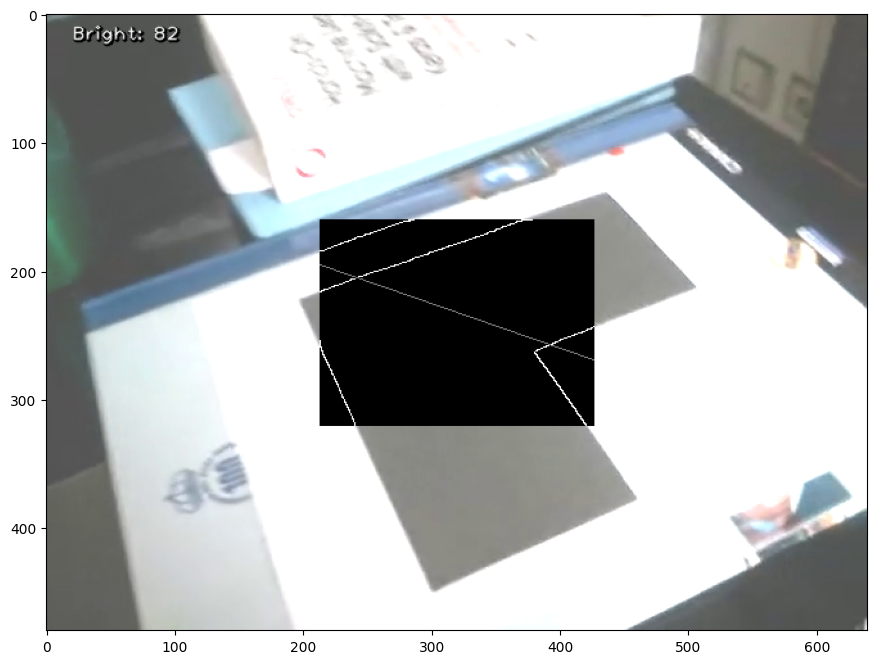

In [15]:
#@markdown Sliders enteros (brillo/umbrales de Canny) y elección RGB/Gray.

bright = 210         #@param {type: "slider", min: 0, max: 255}
th1 = 31            #@param {type: "slider", min: 0, max: 500}
th2 = 200            #@param {type: "slider", min: 0, max: 500}
rgb_or_gray = "RGB" #@param ['RGB', 'GRAY']

####################

H,W = imgwc.shape[:2]
imgproc = processing(imgwc, (W//3,2*W//3), (H//3,2*H//3),
                     rgb_or_gray=='RGB', bright,(th1,th2))
mpld3.enable_notebook()
plt.figure(figsize=(12,8))
plt.imshow(imgproc,cmap='gray')
plt.show()
mpld3.disable_notebook()

El código es algo más sencillo (*) y responsivo, aunque, por supuesto, una vez seleccionados los parámetros de interés para nosotros, se exige la ejecución manual de la celda para que tengan efecto en la ejecución.

(\*) **Nota**: De nuevo, se dispone de muchas posibilidades (pulsar en la izquierda el icono "<>" ("Fragmentos de código"), y buscar la opción "Adding Form Fields") para ver todas las posibilidades.

# Problemas de la estimación por mínimos cuadrados

El código de ejemplo anterior que, en un ROI de imagen, computaba los bordes prominentes mediante el algoritmo de Canny, y sobre los puntos extraídos realizaba un ajuste de la posible recta presente por mínimos cuadrados, es un típico ejemplo de la **falta de robustez** (en el sentido estadístico) de esta técnica: si en la región de interés, además de la recta dominante, aparecen algunos píxeles de borde _extra_, que no se ajustan al modelo, éstos tienden a distorsionar apreciablemente la recta estimada.

En estos casos se hace necesario, pues, aplicar una técnica estadística robusta que permita aislar los denominados _outliers_ (puntos que NO se ajustan al modelo) de forma previa, para que la estimación posterior de la recta no se vea distorsionada. Las técnicas de la **transformada de Hough**, y, sobre todo, la más moderna **RANSAC** son las que suelen utilizarse para ello.

# RANSAC y HT en skimage y opencv

Para un ajuste robusto de rectas en presencia de outliers, en OpenCV podemos apoyarnos en la Transformada de Hough con `cv.HoughLines` y `cv.HoughLinesP` ([enlace](https://docs.opencv.org/4.x/d9/db0/tutorial_hough_lines.html)). En scikit-image, por su parte, la HT está disponible con `hough_line` y `probabilistic_hough_line` ([enlace](https://scikit-image.org/docs/0.25.x/auto_examples/edges/plot_line_hough_transform.html)), mientras que RANSAC se expone de forma genérica con `skimage.measure.ransac` ([enlace](https://scikit-image.org/docs/0.24.x/api/skimage.measure.html#skimage.measure.ransac)), usando modelos como `LineModel2D` ([enlace](https://scikit-image.org/docs/0.24.x/auto_examples/transform/plot_ransac.html)). Por cierto, que en skimage también están disponibles los modelos `CircleModel` y `ElipseModel`, como ejemplos adicionales para usar también este RANSAC genérico con ellos.

Finalmente, y ya en el ámbito de otros usos más generales de estas técnicas de estimación robusta (no limitados a la estimación de rectas), se encontrarían las funciones más utilizadas para la estimación de homografías / afinidades, tanto en [opencv](https://docs.opencv.org/4.x/d7/dff/tutorial_feature_homography.html) como en [skimage](https://scikit-image.org/docs/0.25.x/auto_examples/transform/plot_matching.html). O incluso en estimación de geometría epipolar, para realizaciones de reconstrucciones 3D a partir de dos o más imágenes ([opencv](https://docs.opencv.org/3.4/d9/d0c/group__calib3d.html?utm_source=chatgpt.com), [skimage](https://scikit-image.org/docs/0.24.x/auto_examples/transform/plot_fundamental_matrix.html)), aunque esto último quede ya inicialmente fuera del alcance de este curso.

